# Análisis de Reseñas Trustpilot: Xero (www.xero.com)
**Caso Práctico Deep Learning — Módulo Final de Machine Learning**

Este notebook realiza un análisis integral de las reseñas de **Xero** en Trustpilot empleando técnicas de *Natural Language Processing (NLP)*. El análisis responde a las siguientes preguntas de negocio planteadas por el director de Customer Experience (CX):

1. ¿La mayoría de las reseñas son positivas o negativas? ¿Y en la competencia?
2. ¿Qué temas tratan las reseñas? ¿Y en la competencia?
3. Por tema: ¿el sentimiento predominante es positivo o negativo? ¿En qué somos mejores/peores que la competencia?
4. Identificación de áreas de mejora.

> ⚠️ **Nota metodológica clave:** Las estrellas del dataset **NO** se utilizan como proxy de sentimiento. El corpus ha sido balanceado artificialmente (20 reseñas por cada nivel de estrellas para cada empresa), lo que invalida su uso como etiqueta supervisada. En su lugar se emplea el modelo **CardiffNLP `twitter-roberta-base-sentiment-latest`**.

---
| Parámetro | Valor |
|-----------|-------|
| Empresa objetivo | `www.xero.com` |
| Sector | Business Services |
| Dataset | Trustpilot Reviews 123k |
| Modelo de sentimiento | CardiffNLP RoBERTa |
| Topic Modeling | BERTopic (Sentence Transformers + UMAP + HDBSCAN) |
| Nº competidores | 5 empresas del mismo sector |

---
## 0. Instalación de Dependencias

Ejecuta esta celda solo si es la primera vez que corres el notebook en el entorno.

In [172]:
# Librerías de NLP y visualización
%pip install transformers torch pandas numpy matplotlib seaborn wordcloud regex --quiet
# BERTopic y dependencias para topic modeling neuronal
%pip install bertopic sentence-transformers umap-learn hdbscan --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Importación de Librerías

In [173]:
import re
import regex
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display

# HuggingFace Transformers: Análisis de sentimiento con RoBERTa
from transformers import pipeline

# BERTopic: Topic Modeling neuronal basado en embeddings
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN

# Configuración estética global
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Paleta de colores semántica para sentimiento
PALETTE = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## 2. Configuración Global del Análisis

Centralizamos todos los parámetros para garantizar la **reproducibilidad** del análisis y facilitar la experimentación con diferentes configuraciones.

In [174]:
# ── Empresa objetivo ──────────────────────────────────────────────────────────
TARGET = 'www.xero.com'       # Xero: plataforma de contabilidad en la nube para pymes
CAT    = 'Business Services'  # Sector de actividad en el dataset

# ── Competidores seleccionados ────────────────────────────────────────────────
# Criterio: empresas del mismo sector (Business Services) con 100 reseñas,
# orientadas a servicios financieros, SaaS o gestión para pymes.
COMPETITORS = [
    'crunch.co.uk',           # Contabilidad online para autónomos y pymes (competidor directo)
    'www.takepayments.com',   # Soluciones de cobro con tarjeta para pymes
    'skrill.com',             # Pagos digitales globales (fintech)
    'www.clearpay.co.uk',     # Compra ahora, paga después (fintech)
    'eposnow.com',            # Software TPV para pymes (SaaS de gestión)
]
ALL_COMPANIES = [TARGET] + COMPETITORS

# ── Parámetros de Topic Modeling ──────────────────────────────────────────────
N_TOPICS       = 6    # Nº de topics objetivo en BERTopic
MIN_TOPIC_DOCS = 5    # Mínimo de documentos para que un topic sea válido en BERTopic

# ── Stop words de dominio ─────────────────────────────────────────────────────
# Términos tan ubicuos en el corpus que no diferencian topics:
# - nombres de empresa (alto IDF artificialmente por segmentación de corpus)
# - palabras genéricas del vocabulario de reseñas de servicios
DOMAIN_STOP_WORDS = [
    'xero', 'clearpay', 'skrill', 'crunch', 'takepayments', 'eposnow',
    'service', 'customer', 'account', 'support', 'time', 'use', 'used',
    'company', 'get', 'would', 'could', 'also', 'make', 'one', 'product',
    'business', 'just', 'really', 'great', 'good', 'bad', 'like', 'need',
    'know', 'way', 'thing', 'people', 'year', 'day', 'month', 'week',
]

# ── Control de ejecución ──────────────────────────────────────────────────────
BATCH_SIZE = 32    # Tamaño de lote para el pipeline de sentimiento
MAX_ROWS   = None  # None = dataset completo; p.ej. 5000 para pruebas rápidas

print(f'Empresa objetivo : {TARGET}')
print(f'Sector           : {CAT}')
print(f'Competidores     : {", ".join(COMPETITORS)}')
print(f'N_TOPICS         : {N_TOPICS}')

Empresa objetivo : www.xero.com
Sector           : Business Services
Competidores     : crunch.co.uk, www.takepayments.com, skrill.com, www.clearpay.co.uk, eposnow.com
N_TOPICS         : 6


---
## 3. Carga y Exploración Inicial del Dataset

In [175]:
print('Cargando dataset de Trustpilot...')
df = pd.read_csv('trustpilot-reviews-123k.csv')
if MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=42)

print(f'Filas     : {len(df):,}')
print(f'Empresas  : {df["company"].nunique():,}')
print(f'Sectores  : {df["category"].nunique()}')
print(f'Columnas  : {list(df.columns)}')
df.head(3)

Cargando dataset de Trustpilot...
Filas     : 123,181
Empresas  : 1,680
Sectores  : 22
Columnas  : ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [176]:
# Estadísticas descriptivas del dataset global
print('Distribución de reseñas por sector (top 10):')
print(df.groupby('category').size().sort_values(ascending=False).head(10).to_string())

print('\nEstadísticas de longitud de reseña (caracteres):')
df['review_len'] = df['review'].astype(str).str.len()
print(df['review_len'].describe().round(1).to_string())

Distribución de reseñas por sector (top 10):
category
Education & Training         6365
Business Services            6190
Home & Garden                6141
Sports                       6134
Food, Beverages & Tobacco    5895
Shopping & Fashion           5794
Vehicles & Transportation    5765
Money & Insurance            5729
Health & Medical             5646
Utilities                    5636

Estadísticas de longitud de reseña (caracteres):
count    123181.0
mean        358.8
std         314.6
min          10.0
25%         177.0
50%         290.0
75%         440.0
max        9956.0


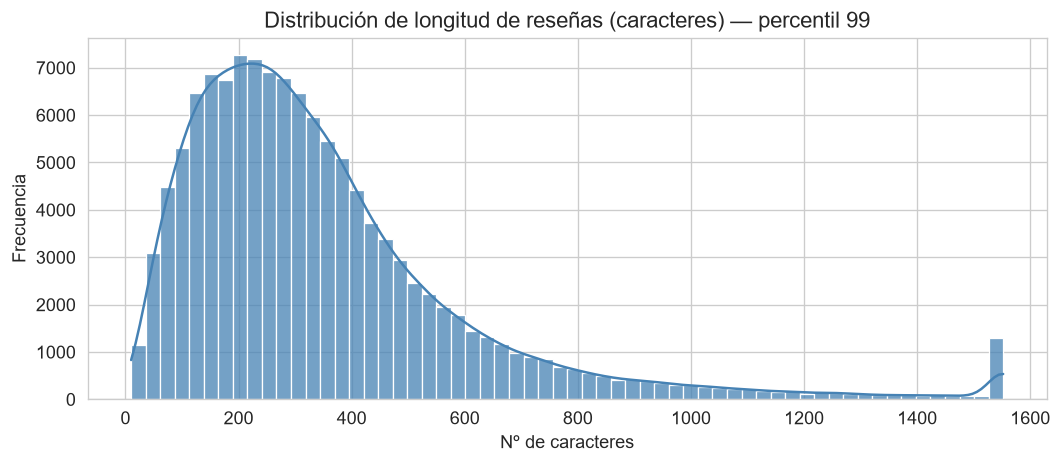

In [177]:
# Distribución de longitud de reseñas — histograma
fig, ax = plt.subplots(figsize=(9, 4))
clip_val = df['review_len'].quantile(0.99)
sns.histplot(df['review_len'].clip(upper=clip_val), bins=60, kde=True,
             color='steelblue', alpha=0.75, ax=ax)
ax.set(title='Distribución de longitud de reseñas (caracteres) — percentil 99',
       xlabel='Nº de caracteres', ylabel='Frecuencia')
plt.tight_layout()
plt.show()

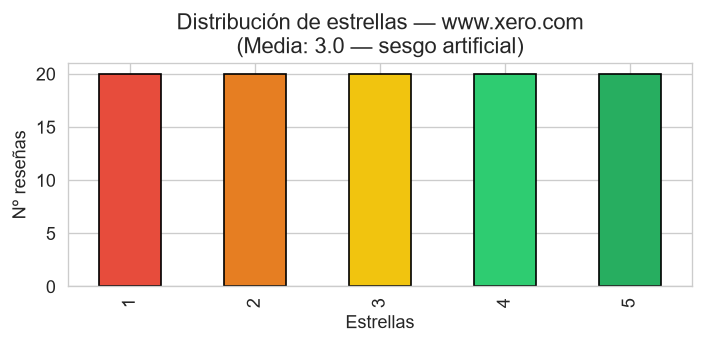

Conclusión: distribución perfectamente uniforme → las estrellas NO se usarán como señal de sentimiento.


In [178]:
# ── Análisis del sesgo en las estrellas ──────────────────────────────────────
# HALLAZGO: el dataset presenta un sesgo de balanceo artificial.
# Cada empresa con 100 reseñas tiene exactamente 20 reseñas por nivel de estrellas,
# lo que hace que la media siempre sea 3.0 y las estrellas carezcan de poder predictivo.
stars_xero = df[df['company'] == TARGET]['stars'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 3))
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
stars_xero.plot(kind='bar', color=colors_bar, edgecolor='black', ax=ax)
ax.set(title=f'Distribución de estrellas — {TARGET}\n'
             f'(Media: {stars_xero.index @ stars_xero.values / stars_xero.sum():.1f} — sesgo artificial)',
       xlabel='Estrellas', ylabel='Nº reseñas')
plt.tight_layout()
plt.show()

print('Conclusión: distribución perfectamente uniforme → las estrellas NO se usarán como señal de sentimiento.')

---
## 4. Exploración Lingüística de las Reseñas

Antes de limpiar el texto identificamos qué patrones de ruido están presentes y con qué frecuencia. Usamos la librería `regex` (superset de `re`) que ofrece soporte a Unicode properties y API directa de `compiled.search()` / `compiled.findall()`.

In [179]:
# Detección de patrones que guiarán la función de limpieza
# Usamos la librería `regex` (superset de `re`) que ofrece:
#   - Soporte a Unicode properties (\p{L}, \p{N}, etc.)
#   - Grupos atómicos y lookbehind de longitud variable
#   - API idéntica a `re`: compiled.search() / compiled.findall()

sample_reviews = df[df['company'] == TARGET]['review'].astype(str)

patterns = {
    'URLs'                : r'https?://\S+|www\.\S+',
    'Saltos de línea'     : r'[\r\n\t]+',
    'Caracteres no-ASCII' : r'[^\x00-\x7F]+',
    'Números aislados'    : r'\b\d+\b',
    'Puntuación múltiple' : r'[!?]{2,}',
}

print(f'Análisis de patrones — {TARGET} ({len(sample_reviews)} reseñas)')
print('-' * 62)
print(f'  {"Patrón":<25}  {"Docs":>4}  {"%Docs":>6}  {"Ocurrencias":>12}')
print('-' * 62)
for name, pat in patterns.items():
    compiled      = regex.compile(pat)
    docs_match    = sample_reviews.apply(lambda x: bool(compiled.search(x)))
    total_matches = sample_reviews.apply(lambda x: len(compiled.findall(x)))
    count = int(docs_match.sum())
    pct   = count / len(sample_reviews) * 100
    total = int(total_matches.sum())
    print(f'  {name:<25}  {count:>4}  {pct:>5.0f}%  {total:>12,}')

Análisis de patrones — www.xero.com (100 reseñas)
--------------------------------------------------------------
  Patrón                     Docs   %Docs   Ocurrencias
--------------------------------------------------------------
  URLs                          0      0%             0
  Saltos de línea               0      0%             0
  Caracteres no-ASCII          14     14%            39
  Números aislados             34     34%            75
  Puntuación múltiple           4      4%             4


In [180]:
# Muestra de reseñas para inspección cualitativa
print(f'--- Muestra de 5 reseñas de {TARGET} ---')
for i, (_, row) in enumerate(df[df['company'] == TARGET].sample(5, random_state=7).iterrows()):
    print(f'\nReseña {i+1} ({row["stars"]} estrellas)')
    print(f'  Título : {row["title"]}')
    print(f'  Texto  : {str(row["review"])[:300]}...')
    print()

--- Muestra de 5 reseñas de www.xero.com ---

Reseña 1 (4 estrellas)
  Título : Xero Central Help
  Texto  : Xero have a system of raising a query with them and waiting for someone to get back to you which works very well indeed.  The staff have all been polite, very knowledgeable, patient and friendly. The only thing that could be better would be to have a dedicated telephone helpline....


Reseña 2 (4 estrellas)
  Título : Good but not perfect 
  Texto  : Xero is pretty good, but it’s not perfect. My company has been using Xero for over 10 years. It does pretty much everything we need but the ways I feel it needs to be improved are:1. The user permissions need more granular customisation. I have been forced to grant an employee full admin access in o...


Reseña 3 (2 estrellas)
  Título : Have been loving Xero for years until recent Sales Invoice Changes
  Texto  : Have been loving Xero for years until their recent use of customers to upgrade their sales invoicing and changes.  Forci

---
## 5. Función de Limpieza de Texto

Diseñamos una función de preprocesamiento que elimina el ruido no lingüístico preservando el contenido semántico que los modelos NLP necesitan.

In [181]:
def clean_text(text: str) -> str:
    """
    Limpia una reseña de Trustpilot eliminando ruido no lingüístico.

    Pasos aplicados (en orden):
    1. Normalizar saltos de línea y tabulaciones a espacio
    2. Eliminar URLs (http/https y www)
    3. Normalizar comillas y apóstrofes tipográficos a ASCII
    4. Eliminar caracteres no-ASCII residuales
    5. Colapsar espacios múltiples
    6. Strip final

    NOTA: Se conservan números, puntuación simple y mayúsculas,
    ya que el tokenizador de RoBERTa y los embeddings de Sentence Transformers
    los manejan correctamente y aportan información semántica.

    Parameters
    ----------
    text : str
        Texto original de la reseña.

    Returns
    -------
    str
        Texto limpio listo para inferencia NLP.
    """
    text = re.sub(r'[\r\n\t]+', ' ', text)           # 1. saltos de línea
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 2. URLs
    text = text.replace('\u2018', "'").replace('\u2019', "'")\
               .replace('\u201c', '"').replace('\u201d', '"')  # 3. comillas tipográficas
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)        # 4. no-ASCII
    text = re.sub(r' +', ' ', text).strip()            # 5-6. espacios
    return text


# Prueba rápida de la función
ejemplo = df[df['company'] == TARGET].iloc[0]
print('Original :', str(ejemplo['review'])[:200])
print('Limpio   :', clean_text(str(ejemplo['review']))[:200])

Original : Was online and got good prompt response at Xero Support.  Hopefully David was a real person and not an AI bot but who knows.
Limpio   : Was online and got good prompt response at Xero Support. Hopefully David was a real person and not an AI bot but who knows.


---
## 6. Filtrado y Construcción del Corpus Analítico

Construimos `df_all`, el corpus de análisis con las 600 reseñas de Xero y sus 5 competidores. Todas las fases de modelado (sentimiento y topics) se ejecutan sobre este corpus compartido para garantizar comparabilidad entre empresas.

In [182]:
# ── Filtrado por empresa ──────────────────────────────────────────────────────
df_target = df[df['company'] == TARGET].copy()
df_comp   = df[df['company'].isin(COMPETITORS)].copy()
df_all    = df[df['company'].isin(ALL_COMPANIES)].copy()

# ── Limpieza y construcción del campo textual combinado ───────────────────────
for frame in [df_target, df_comp, df_all]:
    frame['title_clean']  = frame['title'].astype(str).apply(clean_text)
    frame['review_clean'] = frame['review'].astype(str).apply(clean_text)
    # Concatenamos título y reseña con separador de frase
    frame['text'] = frame['title_clean'] + '. ' + frame['review_clean']

print('Corpus de análisis:')
print(f'  Xero (objetivo)  : {len(df_target):>4} reseñas')
print(f'  Competidores     : {len(df_comp):>4} reseñas ({len(COMPETITORS)} empresas)')
print(f'  Total combinado  : {len(df_all):>4} reseñas')
print()
df_all.groupby('company')[['text']].count().rename(columns={'text': 'n_reseñas'})

Corpus de análisis:
  Xero (objetivo)  :  100 reseñas
  Competidores     :  500 reseñas (5 empresas)
  Total combinado  :  600 reseñas



,n_reseñas
company,
crunch.co.uk,100
eposnow.com,100
skrill.com,100
www.clearpay.co.uk,100
www.takepayments.com,100
www.xero.com,100


---
## 7. Análisis de Sentimiento con RoBERTa

### Modelo: `cardiffnlp/twitter-roberta-base-sentiment-latest`

Utilizamos un modelo **RoBERTa** fine-tuneado por el grupo Cardiff NLP sobre millones de tweets en inglés. Produce tres etiquetas de sentimiento:

| Etiqueta | Interpretación |
|----------|----------------|
| `positive` | Valoración favorable |
| `neutral` | Valoración mixta o neutra |
| `negative` | Valoración desfavorable |

**Justificación:** Las reseñas de Xero están escritas predominantemente en inglés. RoBERTa entrenado sobre texto social informal es especialmente apropiado para el estilo de escritura de Trustpilot. No se realiza fine-tuning adicional: con solo 600 documentos y sin etiquetas fiables (las estrellas están descartadas), el modelo se usa directamente en inferencia (*zero-shot*).

In [183]:
# Carga del pipeline de sentimiento
# max_length=512 y truncation=True gestionan reseñas largas que superan el límite del modelo
print('Cargando modelo cardiffnlp/twitter-roberta-base-sentiment-latest...')
sentiment_pipe = pipeline(
    task       = 'sentiment-analysis',
    model      = 'cardiffnlp/twitter-roberta-base-sentiment-latest',
    tokenizer  = 'cardiffnlp/twitter-roberta-base-sentiment-latest',
    max_length = 512,
    truncation = True,
    device     = -1,  # CPU; cambiar a 0 si se dispone de GPU
)
print('Modelo cargado correctamente')

Cargando modelo cardiffnlp/twitter-roberta-base-sentiment-latest...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17355.38it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente


In [184]:
def apply_sentiment(texts: pd.Series, batch_size: int = BATCH_SIZE) -> pd.DataFrame:
    """
    Aplica el pipeline de análisis de sentimiento sobre una Serie de textos,
    procesando en lotes para optimizar el uso de memoria y velocidad.

    Parameters
    ----------
    texts : pd.Series
        Serie con los textos limpios a clasificar.
    batch_size : int
        Número de textos por lote de inferencia.

    Returns
    -------
    pd.DataFrame
        DataFrame con columnas 'sentiment' (str) y 'confidence' (float).
    """
    results   = []
    text_list = texts.tolist()
    for i in range(0, len(text_list), batch_size):
        batch  = text_list[i : i + batch_size]
        preds  = sentiment_pipe(batch)
        results.extend(preds)
    return pd.DataFrame({
        'sentiment'  : [r['label'].lower() for r in results],
        'confidence' : [round(r['score'], 4) for r in results],
    })


# ── Aplicación sobre el corpus completo ───────────────────────────────────────
print(f'Analizando sentimiento de {len(df_all)} reseñas en lotes de {BATCH_SIZE}...')
sent_df = apply_sentiment(df_all['text'])
df_all  = df_all.reset_index(drop=True)
df_all[['sentiment', 'confidence']] = sent_df

# Actualizar sub-DataFrames con resultados de sentimiento
df_target = df_all[df_all['company'] == TARGET].copy()
df_comp   = df_all[df_all['company'].isin(COMPETITORS)].copy()

print('Distribución de sentimiento (corpus completo):')
print(df_all['sentiment'].value_counts(normalize=True).mul(100).round(1).to_string())

Analizando sentimiento de 600 reseñas en lotes de 32...
Distribución de sentimiento (corpus completo):
sentiment
negative    56.2
positive    36.8
neutral      7.0


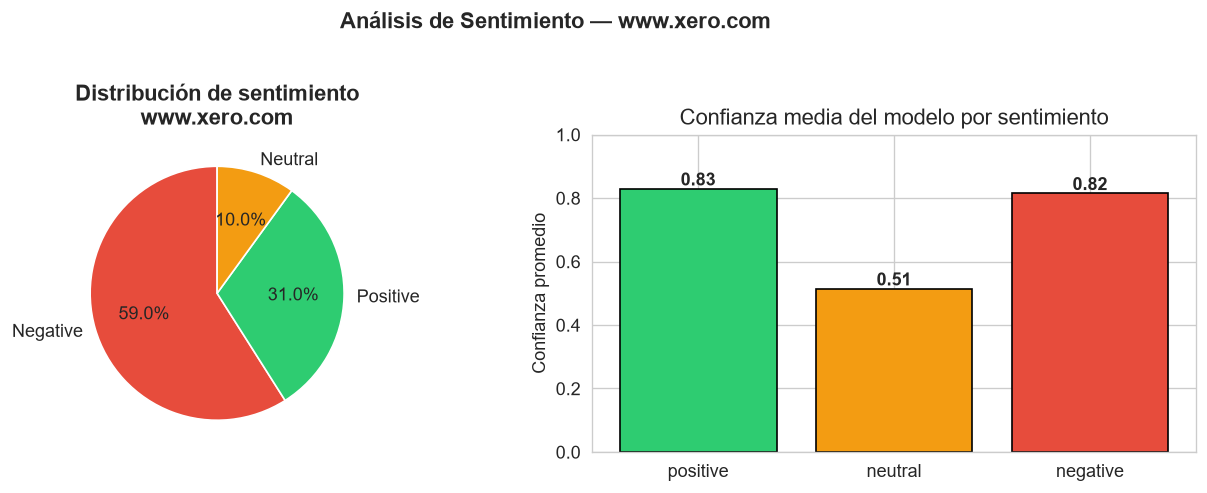

Resumen numérico:
           n_reseñas  porcentaje_%
sentiment                         
negative          59          59.0
positive          31          31.0
neutral           10          10.0


In [185]:
# ── 7.1 Sentimiento global de Xero ────────────────────────────────────────────
sent_xero     = df_target['sentiment'].value_counts()
sent_xero_pct = sent_xero / sent_xero.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico circular: distribución de sentimiento
colors_pie = [PALETTE.get(s, 'gray') for s in sent_xero.index]
axes[0].pie(sent_xero, labels=[s.capitalize() for s in sent_xero.index],
            autopct='%1.1f%%', colors=colors_pie, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title(f'Distribución de sentimiento\n{TARGET}', fontweight='bold')

# Confianza media del modelo por sentimiento
conf_mean   = df_target.groupby('sentiment')['confidence'].mean().reindex(['positive','neutral','negative'])
conf_colors = [PALETTE.get(s, 'gray') for s in conf_mean.index]
bars = axes[1].bar(conf_mean.index, conf_mean.values,
                   color=conf_colors, edgecolor='black')
axes[1].set(title='Confianza media del modelo por sentimiento',
            ylabel='Confianza promedio', ylim=(0, 1))
for bar, val in zip(bars, conf_mean.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f'{val:.2f}', ha='center', fontweight='bold')

plt.suptitle(f'Análisis de Sentimiento — {TARGET}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Resumen numérico:')
print(pd.DataFrame({'n_reseñas': sent_xero, 'porcentaje_%': sent_xero_pct.round(1)}).to_string())

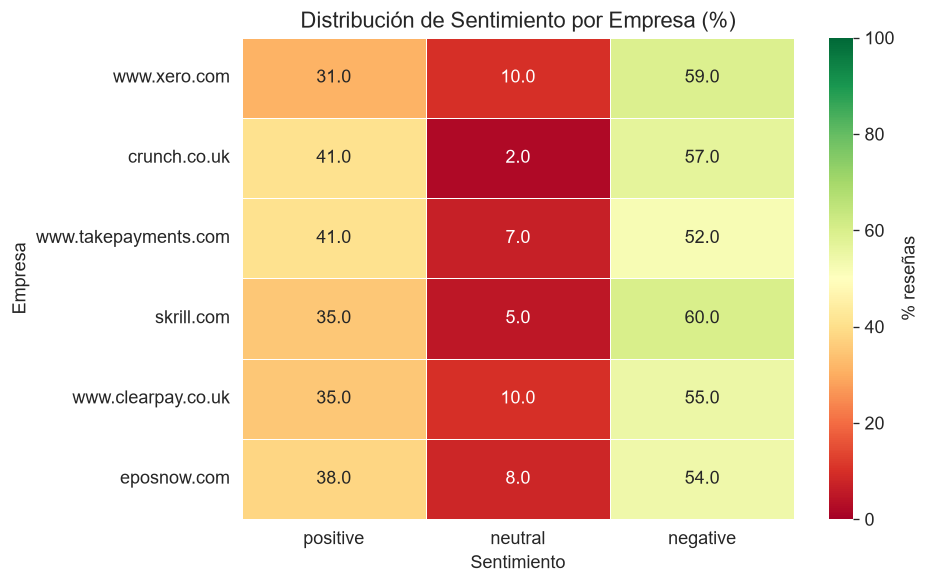

sentiment             positive  neutral  negative
company                                          
www.xero.com              31.0     10.0      59.0
crunch.co.uk              41.0      2.0      57.0
www.takepayments.com      41.0      7.0      52.0
skrill.com                35.0      5.0      60.0
www.clearpay.co.uk        35.0     10.0      55.0
eposnow.com               38.0      8.0      54.0


In [186]:
# ── 7.2 Comparativa de sentimiento: Xero vs Competidores ─────────────────────
sent_by_company = (
    df_all.groupby(['company', 'sentiment'])
          .size()
          .unstack(fill_value=0)
          .apply(lambda x: x / x.sum() * 100, axis=1)
)
cols_order = [c for c in ['positive', 'neutral', 'negative'] if c in sent_by_company.columns]
sent_by_company = sent_by_company[cols_order].reindex([TARGET] + COMPETITORS)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(sent_by_company, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': '% reseñas'})
ax.set(title='Distribución de Sentimiento por Empresa (%)',
       xlabel='Sentimiento', ylabel='Empresa')
plt.tight_layout()
plt.show()

print(sent_by_company.round(1).to_string())

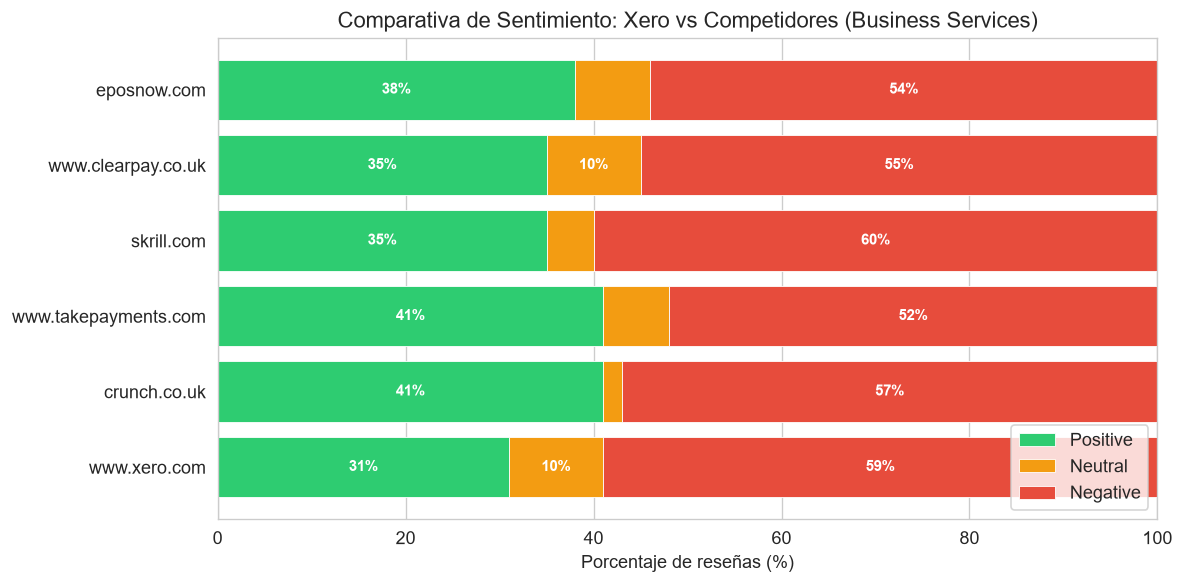

In [187]:
# ── 7.3 Barras apiladas horizontales: comparativa visual ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(sent_by_company))

for sentiment in cols_order:
    values = sent_by_company[sentiment].values
    bars   = ax.barh(sent_by_company.index, values, left=bottom,
                     color=PALETTE[sentiment], label=sentiment.capitalize(),
                     edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
    bottom += values

ax.set(title='Comparativa de Sentimiento: Xero vs Competidores (Business Services)',
       xlabel='Porcentaje de reseñas (%)', xlim=(0, 100))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Topic Modeling con BERTopic

**BERTopic** combina tres componentes para identificar los temas principales de las reseñas:

1. **Sentence Transformers** (`all-MiniLM-L6-v2`): convierte cada reseña en un vector semántico de 384 dimensiones, capturando el significado completo del texto.
2. **UMAP**: reduce los embeddings de alta dimensión a un espacio compacto preservando la estructura local de similitud semántica.
3. **HDBSCAN**: agrupa los vectores reducidos en clusters basados en densidad, siendo cada cluster un topic. Los documentos que no encajan en ningún cluster denso se marcan como outliers (`topic = -1`).

Frente a métodos algebraicos (NMF, LDA), BERTopic captura relaciones semánticas implícitas: *'facturación'* y *'cobros'* quedan en el mismo topic aunque no compartan palabras.

> **Stop words de dominio:** se configura un `CountVectorizer` personalizado que excluye las stop words estándar del inglés más términos genéricos del corpus (nombres de empresa, *service*, *account*, etc.) que saturarían los topics sin aportar información temática.

In [188]:
# ── Paso 1: Embeddings semánticos con Sentence Transformers ──────────────────
# all-MiniLM-L6-v2: excelente equilibrio entre velocidad y calidad semántica
# Cada reseña → vector denso de 384 dimensiones que captura su significado completo
print('Cargando modelo de embeddings all-MiniLM-L6-v2...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

docs = df_all['text'].tolist()
print(f'Calculando embeddings para {len(docs)} documentos...')
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f'Embeddings calculados: shape {embeddings.shape}')

Cargando modelo de embeddings all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5030.08it/s]


Calculando embeddings para 600 documentos...


Batches: 100%|██████████| 10/10 [00:07<00:00,  1.31it/s]

Embeddings calculados: shape (600, 384)


In [189]:

umap_model = UMAP(
    n_neighbors  = 10,        # Vecinos para construir el grafo de similitud local
    n_components = 5,         # Dimensionalidad del espacio reducido (5, no 2, para clustering)
    min_dist     = 0.0,       # 0.0 = clusters más compactos (óptimo para HDBSCAN)
    metric       = 'cosine',  # Apropiado para embeddings de texto normalizados
    random_state = 42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size         = MIN_TOPIC_DOCS,  # Mínimo de docs para formar un topic
    min_samples              = 3,               # Robustez ante outliers
    metric                   = 'euclidean',
    cluster_selection_method = 'eom',           # Excess of Mass: clusters más estables
    prediction_data          = True,
)

vectorizer_model = CountVectorizer(
    stop_words  = list(ENGLISH_STOP_WORDS) + DOMAIN_STOP_WORDS,
    ngram_range = (1, 2),  # Unigramas y bigramas para capturar frases clave
    min_df      = 2,       # Término debe aparecer en >= 2 documentos
)

print('Componentes configurados: UMAP, HDBSCAN, CountVectorizer')

Componentes configurados: UMAP, HDBSCAN, CountVectorizer


In [190]:
# ── Paso 5: Instanciación y entrenamiento de BERTopic ────────────────────────
topic_model = BERTopic(
    embedding_model         = embedding_model,
    umap_model              = umap_model,
    hdbscan_model           = hdbscan_model,
    vectorizer_model        = vectorizer_model,  # Stop words de dominio aplicadas
    nr_topics               = N_TOPICS,          # Merge automático hasta N_TOPICS
    verbose                 = True,
    language                = 'english',
    calculate_probabilities = False,
)

# fit_transform recibe los textos y los embeddings ya calculados (no re-codifica)
topics_bert, _ = topic_model.fit_transform(docs, embeddings)
df_all['topic_bertopic'] = topics_bert

n_topics_found = len(set(topics_bert)) - (1 if -1 in topics_bert else 0)
n_outliers     = topics_bert.count(-1)
print(f'\nTopics encontrados (excl. outliers): {n_topics_found}')
print(f'Documentos asignados como outliers (-1): {n_outliers} ({n_outliers/len(docs)*100:.1f}%)')

2026-06-15 16:24:18,531 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-15 16:24:19,472 - BERTopic - Dimensionality - Completed ✓
2026-06-15 16:24:19,472 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-15 16:24:19,489 - BERTopic - Cluster - Completed ✓
2026-06-15 16:24:19,490 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-15 16:24:19,556 - BERTopic - Representation - Completed ✓
2026-06-15 16:24:19,556 - BERTopic - Topic reduction - Reducing number of topics
2026-06-15 16:24:19,563 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-15 16:24:19,610 - BERTopic - Representation - Completed ✓
2026-06-15 16:24:19,610 - BERTopic - Topic reduction - Reduced number of topics from 29 to 6



Topics encontrados (excl. outliers): 5
Documentos asignados como outliers (-1): 87 (14.5%)


In [191]:
# ── Información de topics BERTopic ───────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print('Topics identificados por BERTopic:')
print('-' * 60)
print(topic_info[topic_info['Topic'] != -1][['Topic', 'Count', 'Name']].to_string(index=False))

print('\nPalabras representativas por topic (top 10):')
print('-' * 60)
for topic_id in sorted(set(topics_bert)):
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
    print(f'  Topic {topic_id}: {", ".join(words)}')

Topics identificados por BERTopic:
------------------------------------------------------------
 Topic  Count                                Name
     0    447                 0_money_new_pay_don
     1     28      1_terminal_phone_problem_emily
     2     25  2_helpful_friendly_clear_extremely
     3      8 3_compliance_pci_pci compliance_ian
     4      5        4_response_clear_query_quick

Palabras representativas por topic (top 10):
------------------------------------------------------------
  Topic 0: money, new, pay, don, payment, ve, using, card, issue, payments
  Topic 1: terminal, phone, problem, emily, sorted, helpful, trying, information, thank, got
  Topic 2: helpful, friendly, clear, extremely, lovely, help, assistance, brilliant, thank, precise
  Topic 3: compliance, pci, pci compliance, ian, card, card machine, cheap, completing, card payment, worst card
  Topic 4: response, clear, query, quick, timely, reasonably, original, efficient, question, fix


In [192]:

TOPIC_LABELS = {
    0: 'Problemas con pagos y cobros',
    1: 'Soporte técnico y resolución de incidencias',
    2: 'Experiencia de atención al cliente',
    3: 'Cumplimiento PCI y configuración de terminal',
    4: 'Calidad y velocidad de respuesta',
}

df_all['topic_label'] = df_all['topic_bertopic'].map(TOPIC_LABELS).fillna('Outlier')
print('Etiquetas asignadas:', TOPIC_LABELS)

Etiquetas asignadas: {0: 'Problemas con pagos y cobros', 1: 'Soporte técnico y resolución de incidencias', 2: 'Experiencia de atención al cliente', 3: 'Cumplimiento PCI y configuración de terminal', 4: 'Calidad y velocidad de respuesta'}


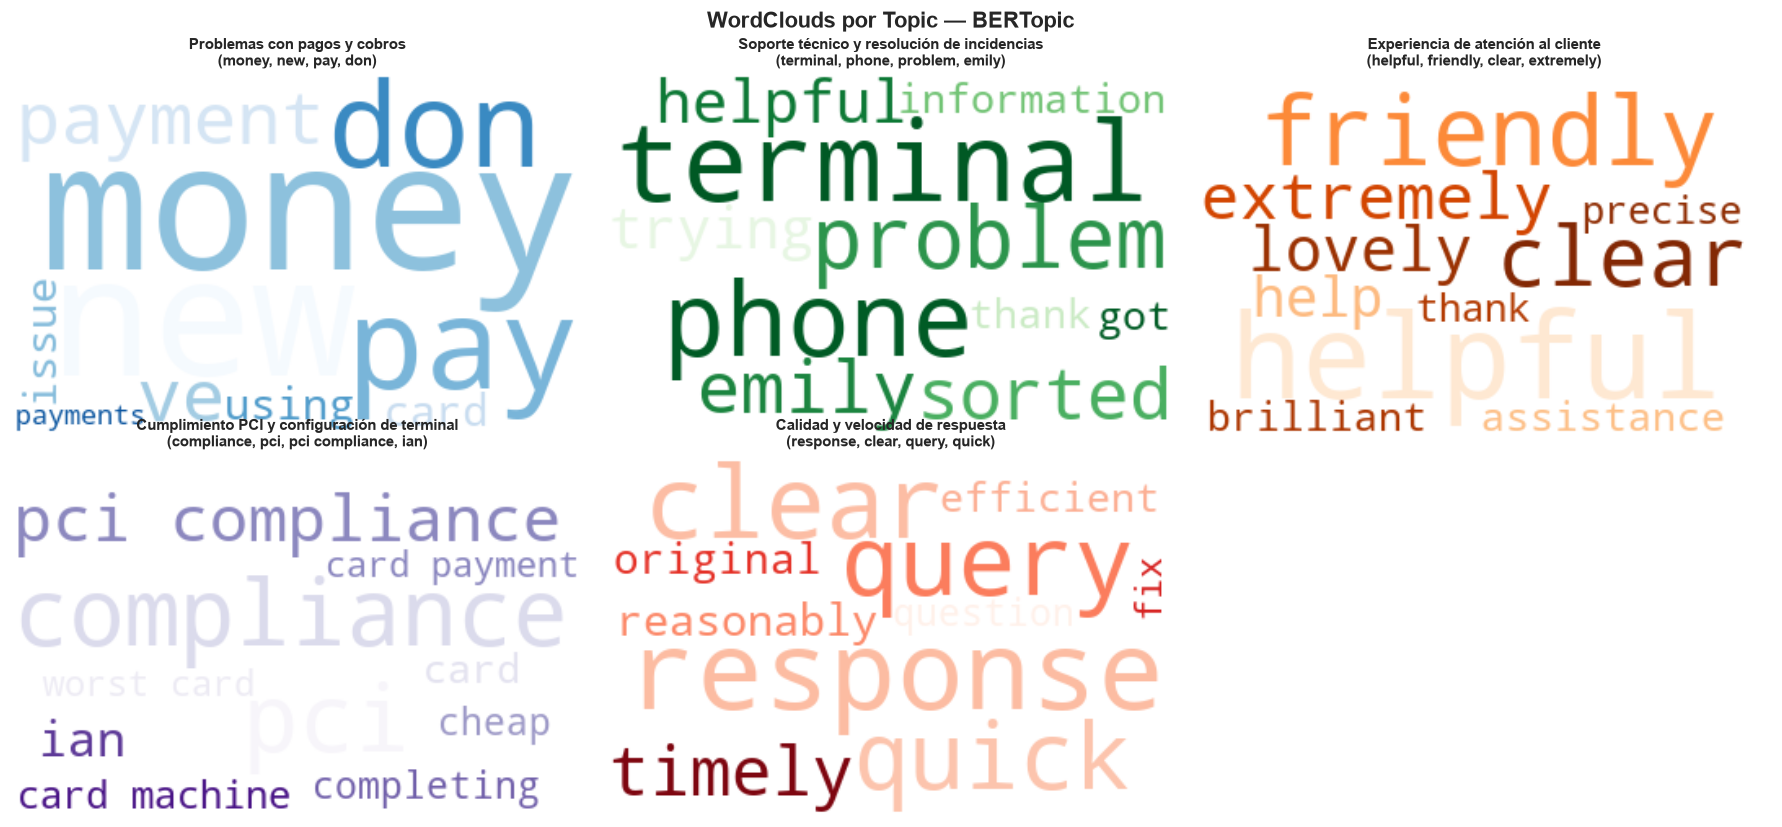

In [193]:
# ── WordClouds por topic BERTopic ─────────────────────────────────────────────
valid_topics = sorted([t for t in set(topics_bert) if t != -1])
n_valid      = len(valid_topics)

cols_wc = min(3, n_valid)
rows_wc = (n_valid + cols_wc - 1) // cols_wc
cmap_list = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlOrBr']

fig, axes = plt.subplots(rows_wc, cols_wc, figsize=(5 * cols_wc, 3.5 * rows_wc))
axes_flat  = np.array(axes).flatten() if n_valid > 1 else [axes]

for i, topic_id in enumerate(valid_topics):
    topic_words_dict = dict(topic_model.get_topic(topic_id))
    wc = WordCloud(
        width=350, height=220, background_color='white',
        colormap=cmap_list[i % len(cmap_list)], max_words=40
    ).generate_from_frequencies(topic_words_dict)
    axes_flat[i].imshow(wc, interpolation='bilinear')
    axes_flat[i].axis('off')
    top4 = ", ".join([w for w, _ in topic_model.get_topic(topic_id)[:4]])
    label = TOPIC_LABELS.get(topic_id, f'Topic {topic_id}')
    axes_flat[i].set_title(f'{label}\n({top4})', fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('WordClouds por Topic — BERTopic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

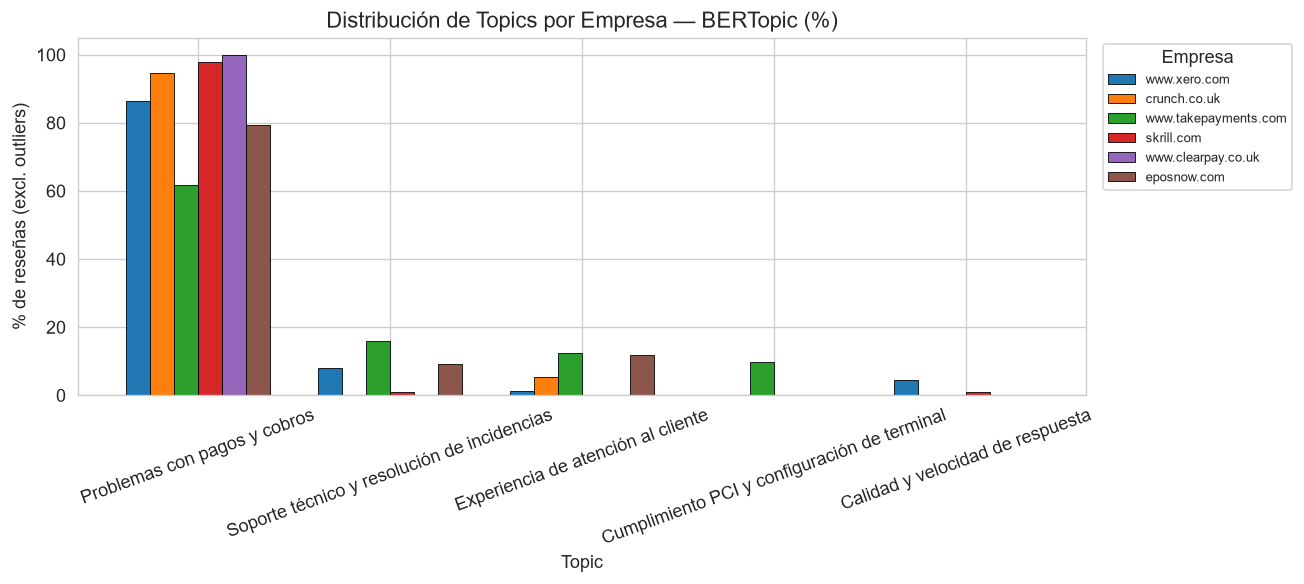

In [194]:
# ── Distribución de topics por empresa ───────────────────────────────────────
df_valid = df_all[df_all['topic_bertopic'] != -1].copy()

topic_dist = (
    df_valid.groupby(['company', 'topic_bertopic'])
            .size()
            .unstack(fill_value=0)
            .apply(lambda x: x / x.sum() * 100, axis=1)
)
topic_dist.columns = [TOPIC_LABELS.get(c, f'Topic {c}') for c in topic_dist.columns]

fig, ax = plt.subplots(figsize=(11, 5))
topic_dist.reindex([TARGET] + COMPETITORS).T.plot(
    kind='bar', ax=ax, edgecolor='black', linewidth=0.5, width=0.75
)
ax.set(title='Distribución de Topics por Empresa — BERTopic (%)',
       xlabel='Topic', ylabel='% de reseñas (excl. outliers)')
ax.legend(title='Empresa', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_tick_params(rotation=20)
plt.tight_layout()
plt.show()

---
## 9. Cruce: Sentimiento × Topic

Combinamos sentimiento y topics para responder a las preguntas clave de negocio:
- ¿Qué temas generan más/menos satisfacción en Xero?
- ¿En qué temas Xero supera a la competencia y en cuáles tiene peor desempeño?

Como métrica agregada definimos el **Net Sentiment Score (NSS)**:

> **NSS = % positivo − % negativo**

Un NSS > 0 indica que el tema genera más satisfacción que insatisfacción; NSS < 0, lo contrario.

*Nota: los documentos clasificados como outliers (topic = -1) se excluyen de este análisis.*

In [195]:
# ── Sentimiento por topic para Xero ──────────────────────────────────────────
df_target_final = df_all[
    (df_all['company'] == TARGET) & (df_all['topic_bertopic'] != -1)
].copy()

sent_by_topic = (
    df_target_final.groupby(['topic_bertopic', 'sentiment'])
                   .size()
                   .unstack(fill_value=0)
)
sent_by_topic_pct = sent_by_topic.div(sent_by_topic.sum(axis=1), axis=0) * 100

# Net Sentiment Score por topic
sent_by_topic_pct['NSS'] = (
    sent_by_topic_pct.get('positive', 0) - sent_by_topic_pct.get('negative', 0)
)
sent_by_topic_pct.index = [TOPIC_LABELS.get(i, f'T{i}') for i in sent_by_topic_pct.index]

print(f'Sentimiento por topic — {TARGET} (%):')
print(sent_by_topic_pct.round(1).to_string())

Sentimiento por topic — www.xero.com (%):
sentiment                                    negative  neutral  positive    NSS
Problemas con pagos y cobros                     71.4     10.4      18.2  -53.2
Soporte técnico y resolución de incidencias      14.3      0.0      85.7   71.4
Experiencia de atención al cliente                0.0      0.0     100.0  100.0
Calidad y velocidad de respuesta                 25.0      0.0      75.0   50.0


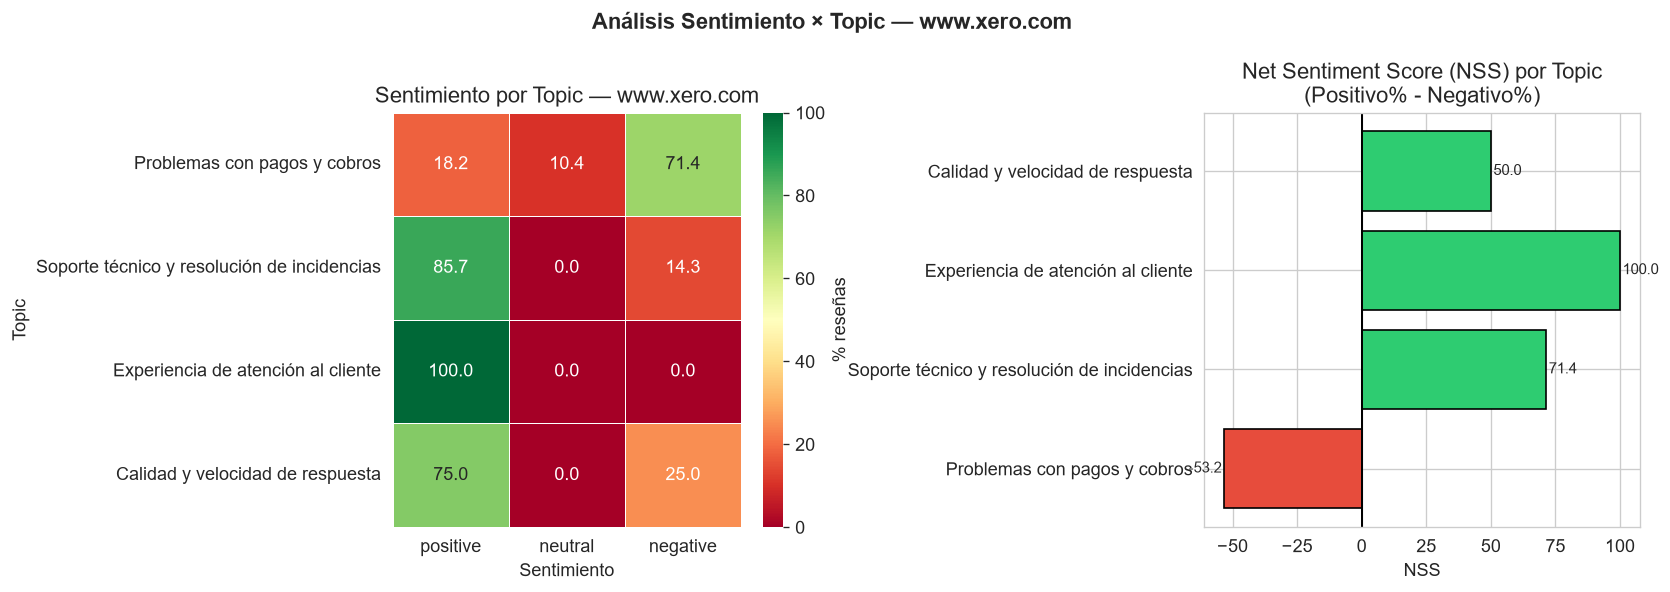

In [196]:
# ── Visualización: heatmap + Net Sentiment Score ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de porcentajes por sentimiento y topic
cols_hm = [c for c in ['positive', 'neutral', 'negative'] if c in sent_by_topic_pct.columns]
sns.heatmap(sent_by_topic_pct[cols_hm], annot=True, fmt='.1f',
            cmap='RdYlGn', ax=axes[0], vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={'label': '% reseñas'})
axes[0].set(title=f'Sentimiento por Topic — {TARGET}',
            xlabel='Sentimiento', ylabel='Topic')

# Net Sentiment Score por topic
nss_vals   = sent_by_topic_pct['NSS']
colors_nss = ['#2ecc71' if v >= 0 else '#e74c3c' for v in nss_vals.values]
axes[1].barh(nss_vals.index, nss_vals.values, color=colors_nss, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set(title='Net Sentiment Score (NSS) por Topic\n(Positivo% - Negativo%)',
            xlabel='NSS')
for i, (label, val) in enumerate(nss_vals.items()):
    offset = 1 if val >= 0 else -1
    ha     = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, i, f'{val:.1f}', va='center', ha=ha, fontsize=9)

plt.suptitle(f'Análisis Sentimiento × Topic — {TARGET}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [197]:
# ── Net Sentiment Score por empresa y topic ──────────────────────────────────
def compute_nss(df_company: pd.DataFrame) -> pd.Series:
    """
    Calcula el Net Sentiment Score (NSS) por topic para una empresa.

    NSS = % reseñas positivas - % reseñas negativas, por topic.
    Los outliers (topic = -1) se excluyen del cálculo.

    Parameters
    ----------
    df_company : pd.DataFrame
        Subconjunto del corpus para una empresa concreta.

    Returns
    -------
    pd.Series
        NSS indexado por topic_bertopic.
    """
    df_filt = df_company[df_company['topic_bertopic'] != -1]
    if df_filt.empty:
        return pd.Series(dtype=float)
    pivot = (
        df_filt.groupby(['topic_bertopic', 'sentiment'])
            .size()
            .unstack(fill_value=0)
    )
    pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
    return pivot.get('positive', 0) - pivot.get('negative', 0)


# Calcular NSS para todas las empresas
nss_dict = {company: compute_nss(df_all[df_all['company'] == company])
            for company in ALL_COMPANIES}

nss_df = pd.DataFrame(nss_dict).T.fillna(0)
nss_df.columns = [TOPIC_LABELS.get(c, f'T{c}') for c in nss_df.columns]

print('Net Sentiment Score por empresa y topic:')
print(nss_df.round(1).to_string())

Net Sentiment Score por empresa y topic:
                      Problemas con pagos y cobros  Soporte técnico y resolución de incidencias  Experiencia de atención al cliente  Cumplimiento PCI y configuración de terminal  Calidad y velocidad de respuesta
www.xero.com                                 -53.2                                         71.4                               100.0                                           0.0                              50.0
crunch.co.uk                                 -24.4                                          0.0                               100.0                                           0.0                               0.0
www.takepayments.com                         -38.0                                        -15.4                               100.0                                         -12.5                               0.0
skrill.com                                   -31.9                                       -100.0                

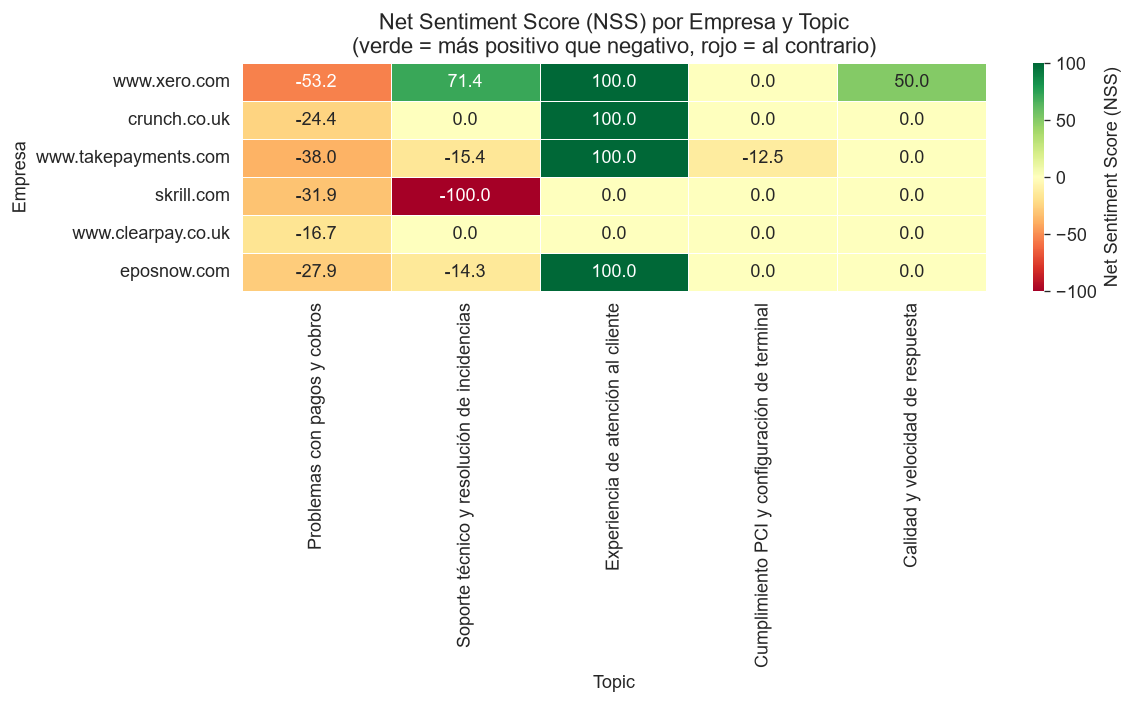

In [198]:
# ── Heatmap comparativo de NSS ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    nss_df.reindex([TARGET] + COMPETITORS),
    annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Net Sentiment Score (NSS)'}
)
ax.set(title='Net Sentiment Score (NSS) por Empresa y Topic\n'
             '(verde = más positivo que negativo, rojo = al contrario)',
       xlabel='Topic', ylabel='Empresa')
plt.tight_layout()
plt.show()

In [199]:
print(f'Ejemplos de reseñas por topic y sentimiento — {TARGET}')
print('=' * 65)
for topic_id in sorted(df_target_final['topic_bertopic'].unique()):
    label = TOPIC_LABELS.get(topic_id, f'Topic {topic_id}')
    for sent_label in ['positive', 'negative']:
        mask   = ((df_target_final['topic_bertopic'] == topic_id) &
                  (df_target_final['sentiment'] == sent_label))
        sample = df_target_final[mask].nlargest(1, 'confidence')
        if len(sample) > 0:
            row = sample.iloc[0]
            print(f'\n[{label} | {sent_label.upper()}] (conf={row["confidence"]:.2f})')
            print(f'Título : {row["title"][:80]}')
            print(f'Reseña : {str(row["review"])[:250]}...')

Ejemplos de reseñas por topic y sentimiento — www.xero.com

[Problemas con pagos y cobros | POSITIVE] (conf=0.98)
Título : Fantastic service from Xero
Reseña : I'm very impressed at the prompt and accurate responses to my enquiries from Xero staff. Sergio GiavonPresidentNorthside Christian Football Club Inc....

[Problemas con pagos y cobros | NEGATIVE] (conf=0.95)
Título : I don't like the fact my price has gone…
Reseña : I don't like the fact my price has gone from £4 to £36! Customer service is awful if I'm honest and I will be looking at different accounting apps moving forward ...

[Soporte técnico y resolución de incidencias | POSITIVE] (conf=0.96)
Título : 5star support
Reseña : 5star support, I had two tickets open for two different team and the persons I spoke with were extremely knowledgeable and helpful.Got my issues sorted, both of them. Thank you for the super support....

[Soporte técnico y resolución de incidencias | NEGATIVE] (conf=0.93)
Título : It should be named zero

---
## 10. Conclusiones y Áreas de Mejora

Síntesis de los hallazgos del análisis para dar respuesta a las cuatro preguntas de negocio planteadas por el director de Customer Experience.

In [204]:
# ── Resumen ejecutivo automatizado ───────────────────────────────────────────
print('=' * 65)
print(f'ANÁLISIS DE RESEÑAS TRUSTPILOT — {TARGET.upper()}')
print('=' * 65)

# 1. Sentimiento global
xero_sent_pct = df_target_final['sentiment'].value_counts(normalize=True) * 100
print('\n1. SENTIMIENTO GLOBAL (Xero):')
for s in ['positive', 'neutral', 'negative']:
    val = xero_sent_pct.get(s, 0)
    print(f'   {s.capitalize():<10}: {val:.1f}%')

# 2. Posición relativa en el sector
print('\n2. POSICION RELATIVA EN EL SECTOR (Business Services):')
avg_pos_sector = sent_by_company.get('positive', pd.Series(dtype=float))
if len(avg_pos_sector) > 0:
    xero_pos    = avg_pos_sector.get(TARGET, 0)
    sector_mean = avg_pos_sector.mean()
    delta       = xero_pos - sector_mean
    print(f'   Xero (% positivo)   : {xero_pos:.1f}%')
    print(f'   Media sector        : {sector_mean:.1f}%')
    print(f'   Diferencial         : {delta:+.1f} pp {"↑" if delta >= 0 else "↓"}')

# 3. Topics por NSS (peor a mejor)
xero_nss = nss_df.loc[TARGET].sort_values() if TARGET in nss_df.index else pd.Series()
print('\n3. TOPICS ORDENADOS POR NET SENTIMENT SCORE:')
for topic_label, score in xero_nss.items():
    marker = 'MEJORAR' if score < 0 else ('BUENO' if score > 20 else 'ESTANDAR')
    print(f'   {topic_label:<25}: NSS = {score:+.1f}  {marker}')

# 4. Áreas de mejora
print('\n4. AREAS DE MEJORA PRIORITARIAS (topics con NSS más bajo):')
if len(xero_nss) >= 2:
    for topic_label in xero_nss.index[:2]:
        score = xero_nss[topic_label]
        if topic_label in nss_df.columns:
            best_comp = nss_df[topic_label].drop(TARGET, errors='ignore').idxmax()
            best_nss  = nss_df[topic_label].drop(TARGET, errors='ignore').max()
            print(f'   • {topic_label}')
            print(f'     NSS Xero = {score:+.1f} | Mejor competidor: {best_comp} (NSS={best_nss:+.1f})')
            print(f'     Brecha a cerrar: {best_nss - score:.1f} puntos')

print('=' * 65)

ANÁLISIS DE RESEÑAS TRUSTPILOT — WWW.XERO.COM

1. SENTIMIENTO GLOBAL (Xero):
   Positive  : 27.0%
   Neutral   : 9.0%
   Negative  : 64.0%

2. POSICION RELATIVA EN EL SECTOR (Business Services):
   Xero (% positivo)   : 31.0%
   Media sector        : 36.8%
   Diferencial         : -5.8 pp ↓

3. TOPICS ORDENADOS POR NET SENTIMENT SCORE:
   Problemas con pagos y cobros: NSS = -53.2  MEJORAR
   Cumplimiento PCI y configuración de terminal: NSS = +0.0  ESTANDAR
   Calidad y velocidad de respuesta: NSS = +50.0  BUENO
   Soporte técnico y resolución de incidencias: NSS = +71.4  BUENO
   Experiencia de atención al cliente: NSS = +100.0  BUENO

4. AREAS DE MEJORA PRIORITARIAS (topics con NSS más bajo):
   • Problemas con pagos y cobros
     NSS Xero = -53.2 | Mejor competidor: www.clearpay.co.uk (NSS=-16.7)
     Brecha a cerrar: 36.6 puntos
   • Cumplimiento PCI y configuración de terminal
     NSS Xero = +0.0 | Mejor competidor: crunch.co.uk (NSS=+0.0)
     Brecha a cerrar: 0.0 puntos


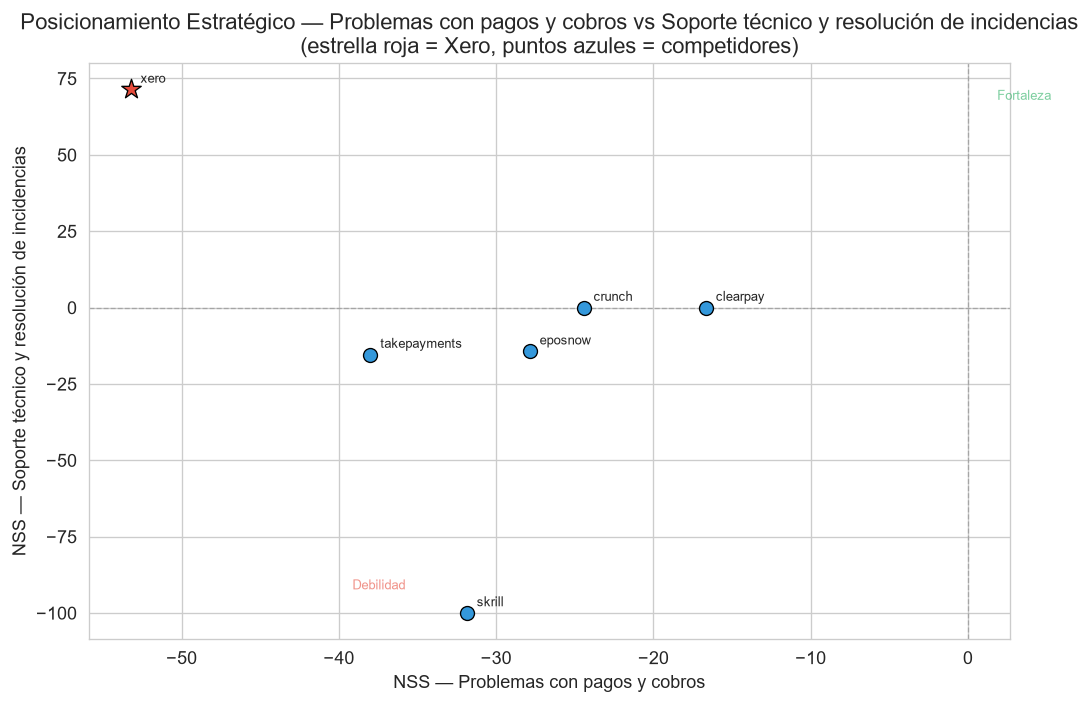

In [ ]:
if len(nss_df.columns) >= 2:
    col_x, col_y = nss_df.columns[0], nss_df.columns[1]

    fig, ax = plt.subplots(figsize=(9, 6))
    for company in nss_df.index:
        x      = nss_df.loc[company, col_x]
        y      = nss_df.loc[company, col_y]
        color  = '#e74c3c' if company == TARGET else '#3498db'
        size   = 150 if company == TARGET else 70
        marker = '*' if company == TARGET else 'o'
        ax.scatter(x, y, color=color, s=size, zorder=3,
                   edgecolors='black', linewidth=0.8, marker=marker)
        label  = company.replace('www.', '').replace('.com', '').replace('.co.uk', '')
        ax.annotate(label, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=8)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set(title=f'Posicionamiento Estratégico — {col_x} vs {col_y}\n'
                 f'(estrella roja = Xero, puntos azules = competidores)',
           xlabel=f'NSS — {col_x}', ylabel=f'NSS — {col_y}')
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.text(xlim[1]*0.7, ylim[1]*0.85, 'Fortaleza', color='#27ae60', fontsize=8, alpha=0.6)
    ax.text(xlim[0]*0.7, ylim[0]*0.85, 'Debilidad', color='#e74c3c', fontsize=8, alpha=0.6)
    plt.tight_layout()
    plt.show()